<a href="https://colab.research.google.com/github/hst8486-collab/thuc-hanh--deep-learning/blob/main/B%C3%A0i_th%E1%BB%B1c_h%C3%A0nh_tu%E1%BA%A7n_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## mô hình autoencoder cho bài toán phân lớp trên bộ dataset Fashion_mnist

#Nạp thư viện

In [1]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

#Nạp dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

# Chuẩn hóa dữ liệu về khoảng [0, 1]
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Duỗi phẳng ảnh 2D (28x28) thành vector 1D (784)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

print("Kích thước x_train:", x_train.shape)
print("Kích thước x_test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Kích thước x_train: (60000, 784)
Kích thước x_test: (10000, 784)


# Xây dựng mô hình Autoencoder

In [3]:
# Kích thước của không gian ẩn (chỉ còn 32 chiều)
encoding_dim = 32

# Lớp đầu vào
input_img = keras.Input(shape=(784,))

# Lớp Encoder (Mã hóa)
encoded = layers.Dense(encoding_dim, activation='relu')(input_img)

# Lớp Decoder (Giải mã)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Khởi tạo mô hình Autoencoder tổng thể (từ đầu vào đến đầu ra tái tạo)
autoencoder = keras.Model(input_img, decoded)

# Khởi tạo mô hình Encoder rời (để trích xuất đặc trưng sau này)
encoder = keras.Model(input_img, encoded)

# Khởi tạo mô hình Decoder rời
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

# Huấn luyện mô hình

In [4]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Bắt đầu huấn luyện...")
autoencoder.fit(x_train, x_train,
                epochs=50,
                batch_size=256,
                verbose=1,
                shuffle=True,
                validation_data=(x_test, x_test))

Bắt đầu huấn luyện...
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.0121 - loss: 0.2741 - val_accuracy: 0.0125 - val_loss: 0.1876
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0132 - loss: 0.1697 - val_accuracy: 0.0113 - val_loss: 0.1527
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0104 - loss: 0.1442 - val_accuracy: 0.0106 - val_loss: 0.1339
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0109 - loss: 0.1279 - val_accuracy: 0.0088 - val_loss: 0.1197
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.0110 - loss: 0.1168 - val_accuracy: 0.0112 - val_loss: 0.1113
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0111 - loss: 0.1096 - val_accuracy: 0.0122 - val_loss: 0.1057
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0115 - loss: 0.1046 - val_accuracy: 0.0127 - val_loss: 0.1012
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0111 - l

# Dự báo ảnh

In [5]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


#Hiển thị ảnh

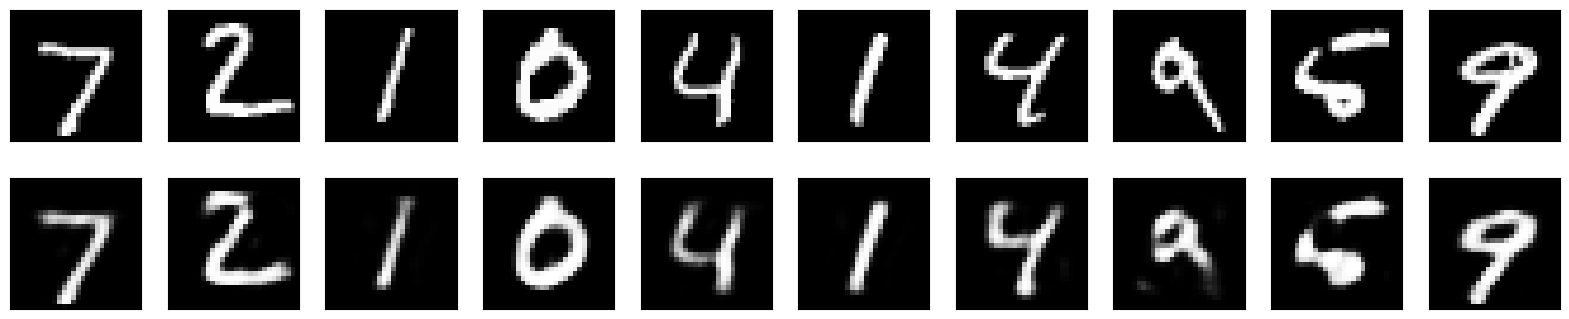

In [6]:
n = 10  # Số lượng ảnh muốn hiển thị
plt.figure(figsize=(20, 4))
for i in range(n):
    # Hiển thị ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Hiển thị ảnh sau khi qua Autoencoder tái tạo
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

#Autoencoder nhận dạng ảnh Cat hoặc Dog

# Import thư viện

In [25]:
!pip install kagglehub
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
from google.colab import files
from PIL import Image
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import io

# Tiền xử lí dữ liệu

In [15]:
path = kagglehub.dataset_download("chetankv/dogs-cats-images")
print("Đã tìm thấy dataset tại:", path)

# Định nghĩa kích thước ảnh
IMG_SIZE = (64, 64)
BATCH_SIZE = 64

# 1.2 Trỏ đường dẫn tới đúng thư mục training
data_dir = os.path.join(path, "dataset", "training_set")
print(f"Đang đọc ảnh trực tiếp từ: {data_dir}")

# 1.3 Load dữ liệu tạo pipeline
train_dataset = keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

def process_data(x):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x

train_dataset = train_dataset.map(process_data).cache().prefetch(tf.data.AUTOTUNE)

100%|██████████| 435M/435M [00:05<00:00, 76.5MB/s]

Extracting files...


Đã tìm thấy dataset tại: /root/.cache/kagglehub/datasets/chetankv/dogs-cats-images/versions/1
Đang đọc ảnh trực tiếp từ: /root/.cache/kagglehub/datasets/chetankv/dogs-cats-images/versions/1/dataset/training_set
Found 8000 files.


# Xây dựng mô hình Autoencoder

In [16]:
input_img = keras.Input(shape=(64, 64, 3)) # Ảnh màu có 3 kênh (RGB)

# Bộ Mã Hóa (Encoder) - Dùng Tích chập (Convolution) để rút trích đặc trưng
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # Nén không gian từ 64x64 -> 32x32

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Nén từ 32x32 -> 16x16 (Latent Space)

# Bộ Giải Mã (Decoder) - Khôi phục lại ảnh
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x) # Phóng to từ 16x16 -> 32x32

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # Phóng to từ 32x32 -> 64x64

# Lớp Output: Dùng hàm sigmoid để trả về giá trị pixel từ 0 đến 1, với 3 kênh màu
decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse') # Lỗi Mean Squared Error thường chạy tốt với ảnh màu

autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

# Huấn luyện mô hình

In [17]:
print("Bắt đầu huấn luyện...")
# Do dữ liệu lớn, ta test thử với 10 epochs trước
history = autoencoder.fit(
    train_dataset,
    epochs=10
)

Bắt đầu huấn luyện...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - loss: 0.0213
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 970ms/step - loss: 0.0088
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 987ms/step - loss: 0.0074
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 982ms/step - loss: 0.0067
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - loss: 0.0063
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 125s 996ms/step - loss: 0.0061
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - loss: 0.0059
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 123s 986ms/step - loss: 0.0058
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 987ms/step - loss: 0.0056
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - loss: 0.0056


# Hiển thị kết quả

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


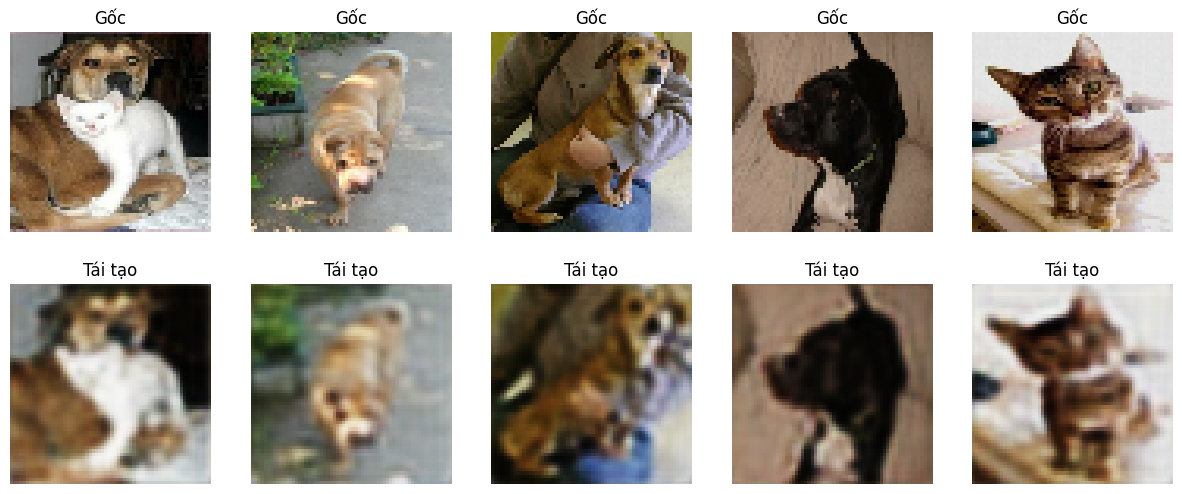

In [18]:
for batch, _ in train_dataset.take(1):
    test_images = batch.numpy()
    break

# Chạy ảnh qua Autoencoder để khôi phục
reconstructed_images = autoencoder.predict(test_images)

# Trực quan hóa
n = 5 # Số ảnh muốn xem
plt.figure(figsize=(15, 6))
for i in range(n):
    # Cột trên: Ảnh gốc
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_images[i])
    plt.title("Gốc")
    plt.axis('off')

    # Cột dưới: Ảnh được tái tạo
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed_images[i])
    plt.title("Tái tạo")
    plt.axis('off')

plt.show()

#nhận dạng chó, mèo

Hãy chọn một bức ảnh chó hoặc mèo từ máy tính của bạn:


Saving chó3.jpg to chó3.jpg

Đang xử lý file: "chó3.jpg"...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


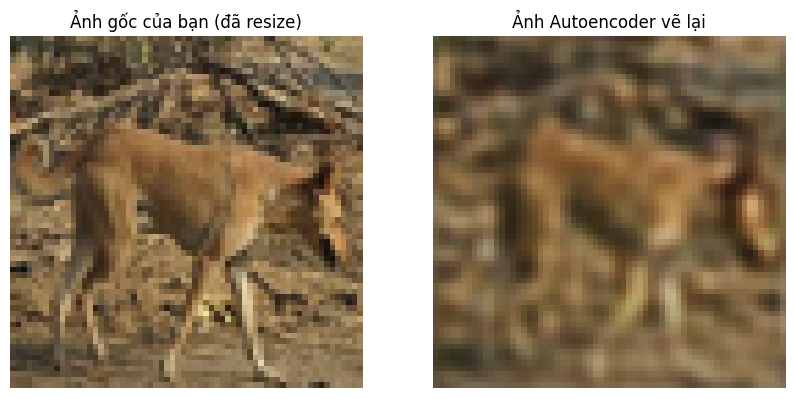

In [31]:
print("Hãy chọn một bức ảnh chó hoặc mèo từ máy tính của bạn:")
uploaded = files.upload()

# 2. Xử lý ảnh sau khi tải lên
for file_name in uploaded.keys():
    print(f'\nĐang xử lý file: "{file_name}"...')

    # Đọc dữ liệu ảnh từ bộ nhớ tạm của Colab
    img = Image.open(io.BytesIO(uploaded[file_name]))

    # Chuyển ảnh về hệ màu RGB (phòng trường hợp bạn up ảnh PNG có nền trong suốt 4 kênh màu)
    img = img.convert('RGB')

    # Ép kích thước về đúng 64x64 như lúc huấn luyện mô hình
    img_resized = img.resize((64, 64))

    # Chuyển thành mảng số học và chuẩn hóa về khoảng [0, 1]
    img_array = image.img_to_array(img_resized)
    img_array = img_array / 255.0

    # Thêm chiều thứ 4 để tạo thành 1 "batch" chứa 1 ảnh: kích thước (1, 64, 64, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # 3. Cho mô hình Autoencoder dự đoán (tái tạo lại ảnh)
    reconstructed_img = autoencoder.predict(img_batch)

    # 4. Trực quan hóa kết quả
    plt.figure(figsize=(10, 5))

    # Khung 1: Ảnh gốc của bạn (sau khi đã resize về 64x64)
    ax = plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title("Ảnh gốc của bạn (đã resize)")
    plt.axis('off')

    # Khung 2: Ảnh Autoencoder vẽ lại
    ax = plt.subplot(1, 2, 2)
    plt.imshow(reconstructed_img[0])
    plt.title("Ảnh Autoencoder vẽ lại")
    plt.axis('off')

    plt.show()

# Recurrent Neural Network

#Nạp thư viện

In [42]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

#Nạp dữ liệu và chuẩn hóa dữ liệu

In [43]:


# 1. Hàm Tải và tiền xử lý dữ liệu
def get_train_test(url, split_percent=0.8):
    df = pd.read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))

    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    n = len(data)
    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]
    return train_data, test_data, data

# 2. Hàm Đóng gói dữ liệu theo chuỗi
def get_XY(dat, time_steps):
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

# 3. Thực thi
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, data = get_train_test(sunspots_url)

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

print(f"Tổng số dòng dữ liệu: {len(data)}")
print(f"Kích thước tập Train X: {trainX.shape}")

Tổng số dòng dữ liệu: 2820
Kích thước tập Train X: (187, 12, 1)


# Mô hình RNN

In [45]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    # Thêm lớp SimpleRNN
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    # Thêm lớp Dense cho đầu ra
    model.add(Dense(dense_units, activation=activation[1]))
    # Biên dịch mô hình
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model = create_RNN(
    hidden_units=3,
    dense_units=1,
    input_shape=(time_steps, 1),
    activation=['tanh', 'tanh']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (76.00 B)

 Trainable params: 19 (76.00 B)

 Non-trainable params: 0 (0.00 B)

#Huấn luyện mô hình

In [46]:
print("Bắt đầu huấn luyện...")
history = model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=1)

Bắt đầu huấn luyện...
Epoch 1/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0151
Epoch 2/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0096
Epoch 3/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0081
Epoch 4/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0071
Epoch 5/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065
Epoch 6/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059
Epoch 7/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0054
Epoch 8/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051
Epoch 9/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0047
Epoch 10/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0046
Epoch 11/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0044
Epoch 12/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043
Epoch 13/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042
Epoch 14/20
187/187 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 15/20
187/187 ━━━━━━━━━━━━━━━

#Dự báo và biểu đồ đánh giá

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Train RMSE: 0.042
Test RMSE: 0.053


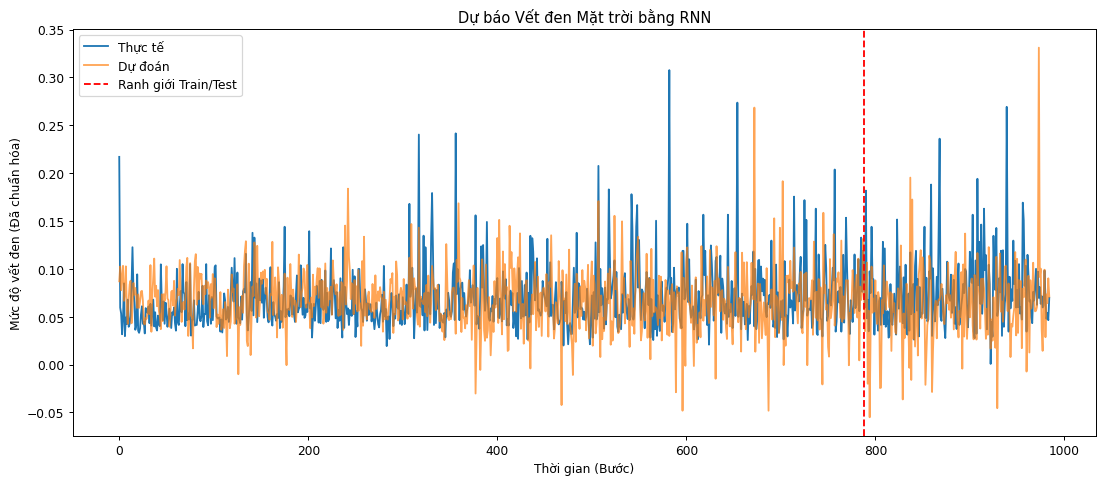


BẢNG KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST (15 BƯỚC ĐẦU TIÊN):
    Giá trị Thực tế  Giá trị Dự đoán  Độ lệch
0                 0                0       -0
1                 0                0       -0
2                 0                0       -0
3                 0                0        0
4                 0               -0       -0
5                 0                0        0
6                 0               -0       -0
7                 0                0       -0
8                 0                0       -0
9                 0                0       -0
10                0                0       -0
11                0                0        0
12                0                0        0
13                0                0       -0
14                0                0       -0


In [56]:
# --- Hàm tính sai số ---
def print_error(trainy, testy, train_predict, test_predict):
    train_rmse = math.sqrt(mean_squared_error(trainy, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testy, test_predict))
    print('Train RMSE: %.3f' % (train_rmse))
    print('Test RMSE: %.3f' % (test_rmse))

# --- Hàm vẽ biểu đồ ---
def plot_result(trainy, testy, train_predict, test_predict):
    actual = np.append(trainy, testy)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=88)
    plt.plot(range(rows), actual, label='Thực tế')
    plt.plot(range(rows), predictions, label='Dự đoán', alpha=0.7)
    plt.axvline(x=len(trainy), color='r', linestyle='--', label='Ranh giới Train/Test')

    plt.legend()
    plt.xlabel('Thời gian (Bước)')
    plt.ylabel('Mức độ vết đen (Đã chuẩn hóa)')
    plt.title('Dự báo Vết đen Mặt trời bằng RNN')
    plt.show()

# --- Thực thi dự báo ---
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# In sai số và vẽ hình
print_error(trainY, testY, train_predict, test_predict)
plot_result(trainY, testY, train_predict, test_predict)

results_df = pd.DataFrame({
    'Giá trị Thực tế': testY.flatten(),
    'Giá trị Dự đoán': test_predict.flatten()
})

# Thêm cột tính toán độ lệch
results_df['Độ lệch'] = results_df['Giá trị Dự đoán'] - results_df['Giá trị Thực tế']

print("\n" + "="*60)
print("BẢNG KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST (15 BƯỚC ĐẦU TIÊN):")
print("="*60)
# Dùng .head(15) để in 15 dòng đầu, tránh làm tràn màn hình
# Bạn có thể đổi thành print(results_df) để xem toàn bộ
print(results_df.head(15))

#Mô hình RNN dự đoán giá nhà

#Import thư viện

In [49]:
!pip install kagglehub
import kagglehub
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

#Nạp và tiền xử lí dữ liệu

In [50]:
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.dataset_download("htagholdings/property-sales")
csv_path = os.path.join(path, "raw_sales.csv")

# Đọc file CSV
df = pd.read_csv(csv_path)

# QUAN TRỌNG: Sắp xếp dữ liệu theo ngày bán (datesold) để tạo chuỗi thời gian chuẩn
df['datesold'] = pd.to_datetime(df['datesold'])
df = df.sort_values(by='datesold')

# Trích xuất cột giá nhà (price) và định dạng lại thành ma trận cột
data_price = np.array(df['price'].values.astype('float32')).reshape(-1, 1)

# Chuẩn hóa dữ liệu về [0, 1] để RNN dễ hội tụ
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_price).flatten()

# Chia tập Train (80%) và Test (20%)
split_percent = 0.8
n = len(data_scaled)
split = int(n * split_percent)
train_data = data_scaled[:split]
test_data = data_scaled[split:]

print(f"Tổng số giao dịch: {n}")
print(f"Số mẫu Train: {len(train_data)} | Số mẫu Test: {len(test_data)}")

Đang tải dữ liệu từ Kaggle...


100%|██████████| 162k/162k [00:00<00:00, 46.4MB/s]

Extracting files...
Tổng số giao dịch: 29580
Số mẫu Train: 23664 | Số mẫu Test: 5916


#Đóng gói dữ liệu

In [51]:
def get_XY(dat, time_steps):
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    # Ép kiểu về ma trận 3 chiều cho RNN: (Số mẫu, time_steps, features)
    X = np.reshape(X, (row_x, time_steps, 1))
    return X, Y

# Dùng 30 giao dịch gần nhất để đoán giá của giao dịch tiếp theo
time_steps = 30
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

#MÔ HÌNH RNN

In [52]:
def create_RNN(hidden_units, dense_units, input_shape, activation):
    model = Sequential()
    model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
    model.add(Dense(dense_units, activation=activation[1]))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Khởi tạo mô hình
model = create_RNN(
    hidden_units=5,  # Tăng lên 5 nơ-ron vì dữ liệu giá nhà biến động phức tạp hơn vết đen
    dense_units=1,
    input_shape=(time_steps, 1),
    activation=['tanh', 'linear'] # Lớp đầu ra dùng 'linear' để dự báo giá trị số thực
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#Huấn luyện mô hình

In [66]:
print("\nBắt đầu huấn luyện...")
# Thêm batch_size=64 để huấn luyện nhanh hơn trên tập dữ liệu lớn

history = model.fit(trainX, trainY, epochs=20, batch_size=64, validation_split=0.1, verbose=1)


Bắt đầu huấn luyện...
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0

#DỰ BÁO VÀ ĐÁNH GIÁ

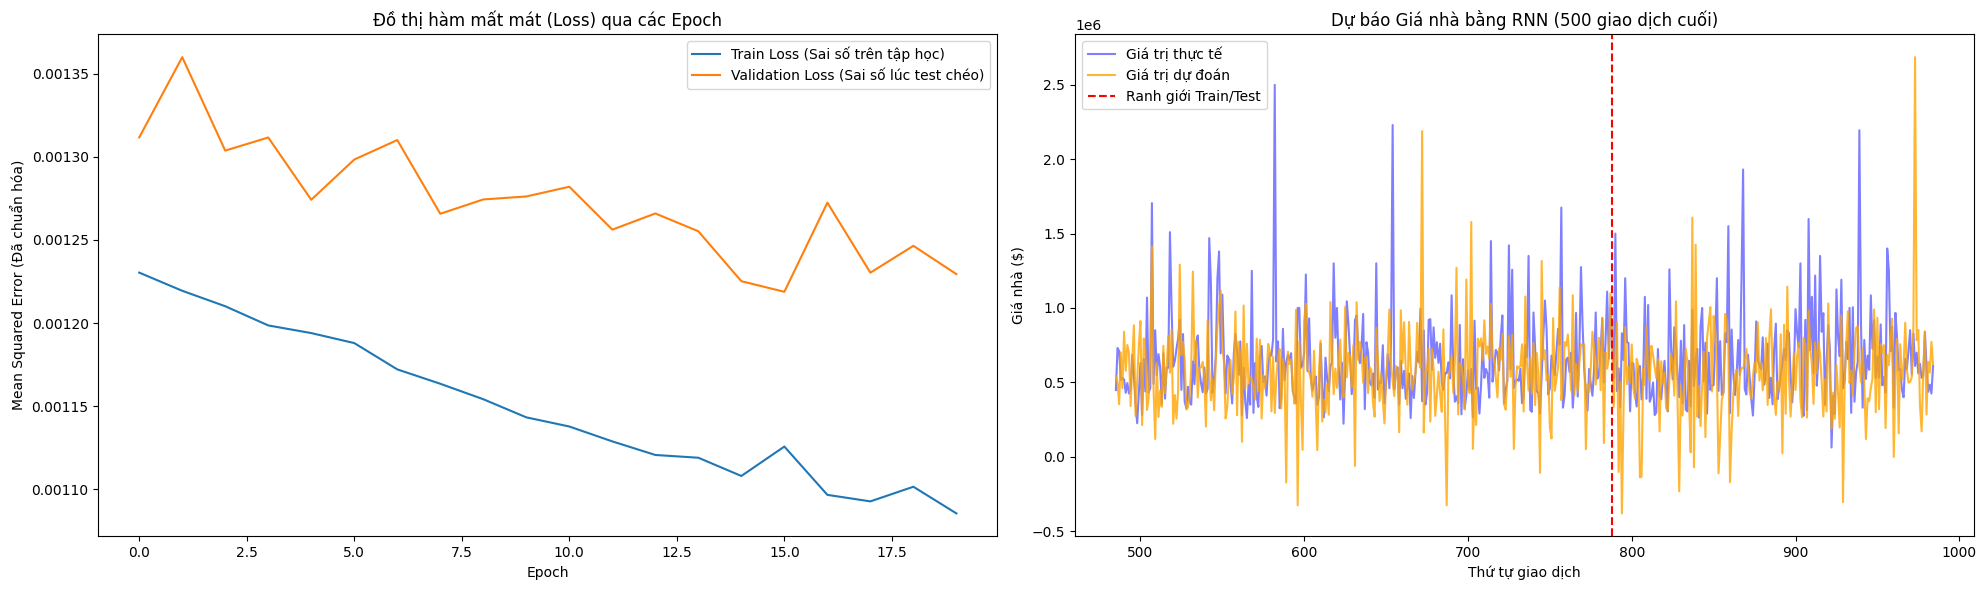

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6), dpi=100)

# Biểu đồ 1: Đồ thị Loss qua từng Epoch
ax1.plot(history.history['loss'], label='Train Loss (Sai số trên tập học)')
ax1.plot(history.history['val_loss'], label='Validation Loss (Sai số lúc test chéo)')
ax1.set_title('Đồ thị hàm mất mát (Loss) qua các Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Mean Squared Error (Đã chuẩn hóa)')
ax1.legend()

# Biểu đồ 2: So sánh Giá trị Dự đoán và Thực tế (Như cũ)
actual = np.append(trainY_real, testY_real)
predictions = np.append(train_predict_real, test_predict_real)
rows = len(actual)
plot_range = 500
start_idx = max(0, rows - plot_range)

ax2.plot(range(start_idx, rows), actual[start_idx:], label='Giá trị thực tế', color='blue', alpha=0.5)
ax2.plot(range(start_idx, rows), predictions[start_idx:], label='Giá trị dự đoán', color='orange', alpha=0.8)
ax2.axvline(x=len(trainY_real), color='red', linestyle='--', label='Ranh giới Train/Test')
ax2.set_title('Dự báo Giá nhà bằng RNN (500 giao dịch cuối)')
ax2.set_xlabel('Thứ tự giao dịch')
ax2.set_ylabel('Giá nhà ($)')
ax2.legend()

plt.tight_layout()
plt.show()

In [68]:


# 1. Tạo một bảng (DataFrame) chứa giá Thực tế và giá Dự đoán của tập Test
results_df = pd.DataFrame({
    'Giá thực tế ($)': testY_real.flatten(),
    'Giá dự đoán ($)': test_predict_real.flatten()
})

# 2. Thêm một cột tính độ chênh lệch (Lấy Dự đoán trừ đi Thực tế)
results_df['Độ chênh lệch ($)'] = results_df['Giá dự đoán ($)'] - results_df['Giá thực tế ($)']

# 3. Định dạng lại các con số cho dễ nhìn (thêm dấu phẩy ngăn cách hàng nghìn, bỏ số thập phân)
pd.options.display.float_format = '{:,.0f}'.format

# 4. In ra 15 giao dịch đầu tiên của tập Test để kiểm tra
print("BẢNG SO SÁNH GIÁ THỰC TẾ VÀ GIÁ MÔ HÌNH DỰ ĐOÁN (15 giao dịch đầu tiên của tập Test):")
print("-" * 70)
print(results_df.head(15))

BẢNG SO SÁNH GIÁ THỰC TẾ VÀ GIÁ MÔ HÌNH DỰ ĐOÁN (15 giao dịch đầu tiên của tập Test):
----------------------------------------------------------------------
    Giá thực tế ($)  Giá dự đoán ($)  Độ chênh lệch ($)
0           795,000          794,888               -112
1           530,000          333,773           -196,227
2         1,500,000          680,105           -819,895
3           441,500          902,671            461,171
4           594,000         -102,387           -696,387
5           333,000          503,500            170,500
6           830,000         -380,986         -1,210,986
7           649,500          338,242           -311,258
8         1,200,000          869,992           -330,008
9           770,000          486,926           -283,074
10          765,000          604,258           -160,742
11          305,000          497,005            192,005
12          631,000          755,062            124,062
13          627,000          457,106           -169,894
14 